# Credit Risk Prediction – Exploratory Data Analysis

## Objective

This notebook performs an exploratory data analysis of the Home Credit
application dataset.

The analysis focuses on:

- Understanding the structure of the dataset.
- Examining the target variable and class imbalance.
- Assessing data quality and missing values.
- Exploring numerical and categorical variables.
- Identifying variables associated with loan default.
- Extracting insights to guide the subsequent modeling stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# Load the Home Credit training dataset.

df = pd.read_csv("application_train.csv")

print("Dataset shape:", df.shape)

Dataset shape: (307511, 122)


## Dataset Structure

The training dataset contains loan application records and includes
both explanatory variables and the target variable.

The target variable, `TARGET`, indicates whether the application resulted
in a loan default.

In [3]:
# Separate predictors and target variable.

X = df.drop(columns=["TARGET"])
y = df["TARGET"]

print("Number of observations:", len(df))
print("Number of features:", X.shape[1])
print("Target variable:", "TARGET")

Number of observations: 307511
Number of features: 121
Target variable: TARGET


## Variable Types

The dataset contains both numerical and categorical variables.

Identifying their types is important because they require different
preprocessing strategies during the modeling stage.

In [4]:
# Identify numerical and categorical features.

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 105
Categorical features: 16


In [5]:
print("\nCategorical features:")
print(categorical_features.tolist())


Categorical features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


## Missing Values

Missing values are common in the Home Credit dataset.

Understanding their distribution is important because missing data will
need to be handled before training the predictive models.

In [6]:
# Calculate missing values and their percentage for each feature.

missing = pd.DataFrame({
    "Missing values": df.isnull().sum(),
    "Missing percentage": df.isnull().mean() * 100
})

missing = missing[
    missing["Missing values"] > 0
].sort_values(
    "Missing percentage",
    ascending=False
)

missing.head(15)

,Missing values,Missing percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953


In [7]:
print(
    f"Features with missing values: "
    f"{missing.shape[0]} of {df.shape[1]}"
)

Features with missing values: 67 of 122


## Target Variable

The target variable is highly imbalanced.

Most applications correspond to non-default cases, while a smaller
proportion of applications correspond to defaults.

This imbalance is important when evaluating classification models,
because accuracy alone may not provide an informative measure of model
performance.

In [8]:
# Calculate target distribution.

target_counts = y.value_counts().sort_index()
target_percentages = y.value_counts(normalize=True).sort_index() * 100

print("Target distribution:")
print(target_counts)

print("\nTarget percentages:")
print(target_percentages.round(2))

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentages:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


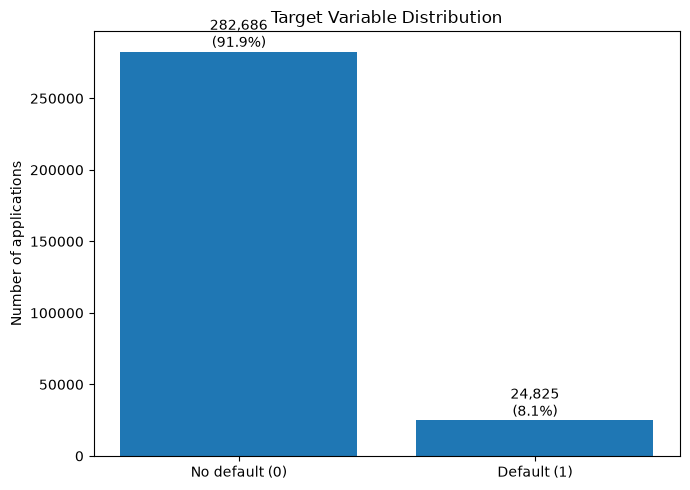

In [9]:
# Create and save the target distribution plot.

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    ["No default (0)", "Default (1)"],
    target_counts.values
)

ax.set_ylabel("Number of applications")
ax.set_title("Target Variable Distribution")

for i, value in enumerate(target_counts.values):
    ax.text(
        i,
        value,
        f"{value:,}\n({target_percentages.iloc[i]:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    figures_dir / "eda_target_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Missing Value Summary

Several variables contain substantial amounts of missing data. Some
building-related variables have missing values in more than two-thirds
of the observations.

Rather than removing observations, the modeling pipeline will handle
missing values through feature-specific imputation strategies.

In [10]:
# Identify features with more than 50% missing values.

high_missing = missing[
    missing["Missing percentage"] > 50
]

print(
    f"Features with more than 50% missing values: "
    f"{len(high_missing)}"
)

high_missing.head(15)

Features with more than 50% missing values: 41


,Missing values,Missing percentage
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953


## Key Numerical Variables

A subset of numerical variables is examined to understand the
distribution of income, credit amounts, demographic characteristics,
and external credit indicators.

These variables are particularly relevant because they are later used
or identified as influential features in the predictive modeling stage.

In [11]:
# Select key numerical variables for exploratory analysis.

key_numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

df[key_numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,9.626928e-01
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,8.549997e-01
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,8.960095e-01


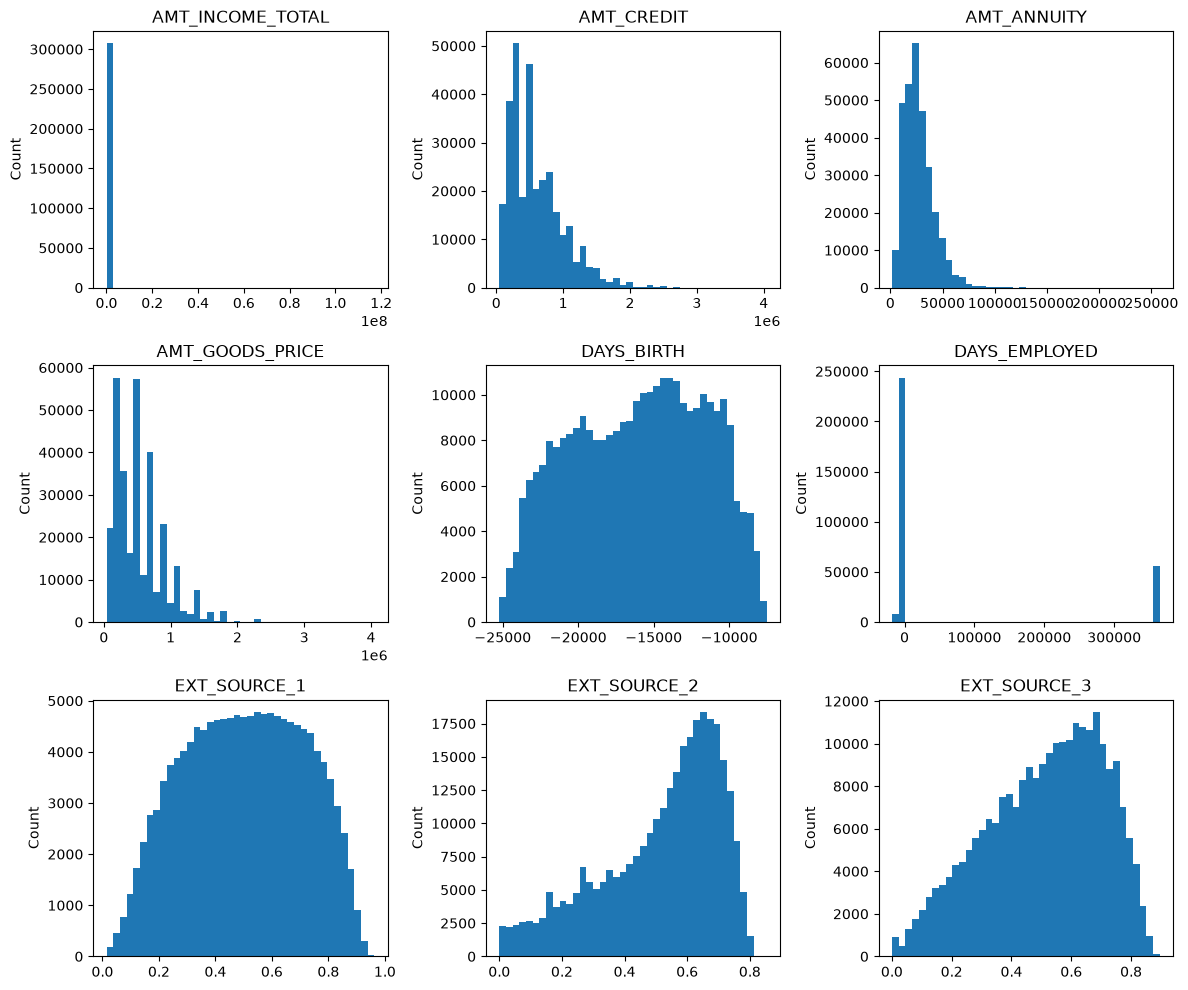

In [12]:
# Plot distributions of selected numerical features.

fig, axes = plt.subplots(
    3, 3,
    figsize=(12, 10)
)

for ax, feature in zip(axes.flat, key_numeric_features):
    ax.hist(
        df[feature].dropna(),
        bins=40
    )
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()

fig.savefig(
    figures_dir / "eda_numeric_distributions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## External Credit Indicators

The `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` variables
represent external credit indicators available in the Home Credit
dataset.

Their distributions are examined separately because these variables
showed strong relationships with the target variable during the
exploratory analysis and later became among the most influential
features in the XGBoost model.

In [13]:
# Compare the external credit indicators.

df[
    ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
EXT_SOURCE_1,134133.0,0.502130,0.211062,1.456813e-02,0.334007,0.505998,0.675053,0.962693
EXT_SOURCE_2,306851.0,0.514393,0.191060,8.173617e-08,0.392457,0.565961,0.663617,0.855000
EXT_SOURCE_3,246546.0,0.510853,0.194844,5.272652e-04,0.370650,0.535276,0.669057,0.896010


In [14]:
# Calculate correlations between numerical features and the target.

target_correlations = (
    df[numeric_features.tolist() + ["TARGET"]]
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values()
)

print("Most negative correlations:")
display(target_correlations.head(10))

print("\nMost positive correlations:")
display(target_correlations.tail(10))

Most negative correlations:


EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64


Most positive correlations:


DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64

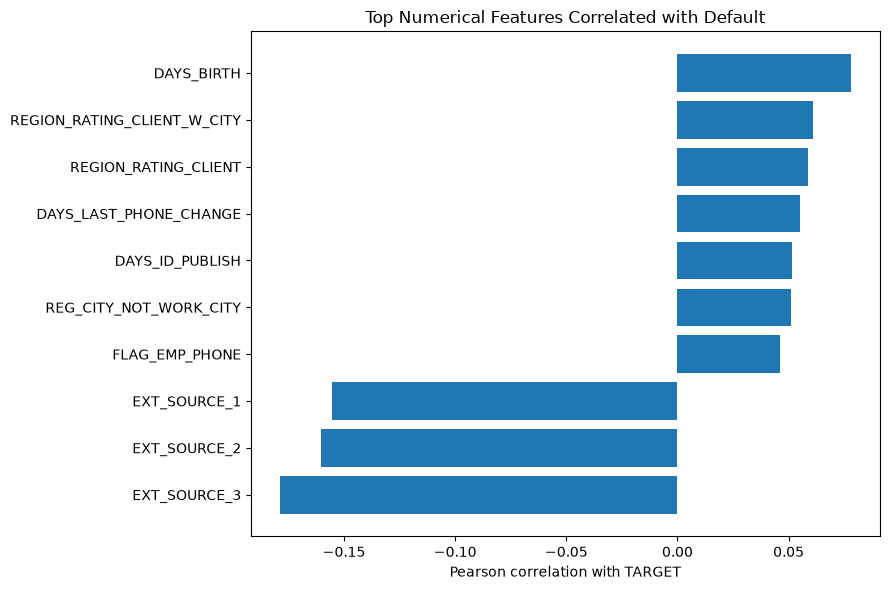

In [15]:
# Select the 10 numerical features with the strongest absolute
# correlation with the target.

top_correlations = (
    target_correlations
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .index
)

correlation_values = target_correlations.loc[top_correlations]
correlation_values = correlation_values.sort_values()

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    correlation_values.index,
    correlation_values.values
)

ax.set_xlabel("Pearson correlation with TARGET")
ax.set_title("Top Numerical Features Correlated with Default")

plt.tight_layout()

fig.savefig(
    figures_dir / "eda_target_correlations.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [16]:
categorical_summary = {}

for feature in [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE"
]:
    categorical_summary[feature] = df[feature].value_counts()

categorical_summary

{'NAME_CONTRACT_TYPE': NAME_CONTRACT_TYPE
 Cash loans         278232
 Revolving loans     29279
 Name: count, dtype: int64,
 'CODE_GENDER': CODE_GENDER
 F      202448
 M      105059
 XNA         4
 Name: count, dtype: int64,
 'NAME_INCOME_TYPE': NAME_INCOME_TYPE
 Working                 158774
 Commercial associate     71617
 Pensioner                55362
 State servant            21703
 Unemployed                  22
 Student                     18
 Businessman                 10
 Maternity leave              5
 Name: count, dtype: int64,
 'NAME_EDUCATION_TYPE': NAME_EDUCATION_TYPE
 Secondary / secondary special    218391
 Higher education                  74863
 Incomplete higher                 10277
 Lower secondary                    3816
 Academic degree                     164
 Name: count, dtype: int64}

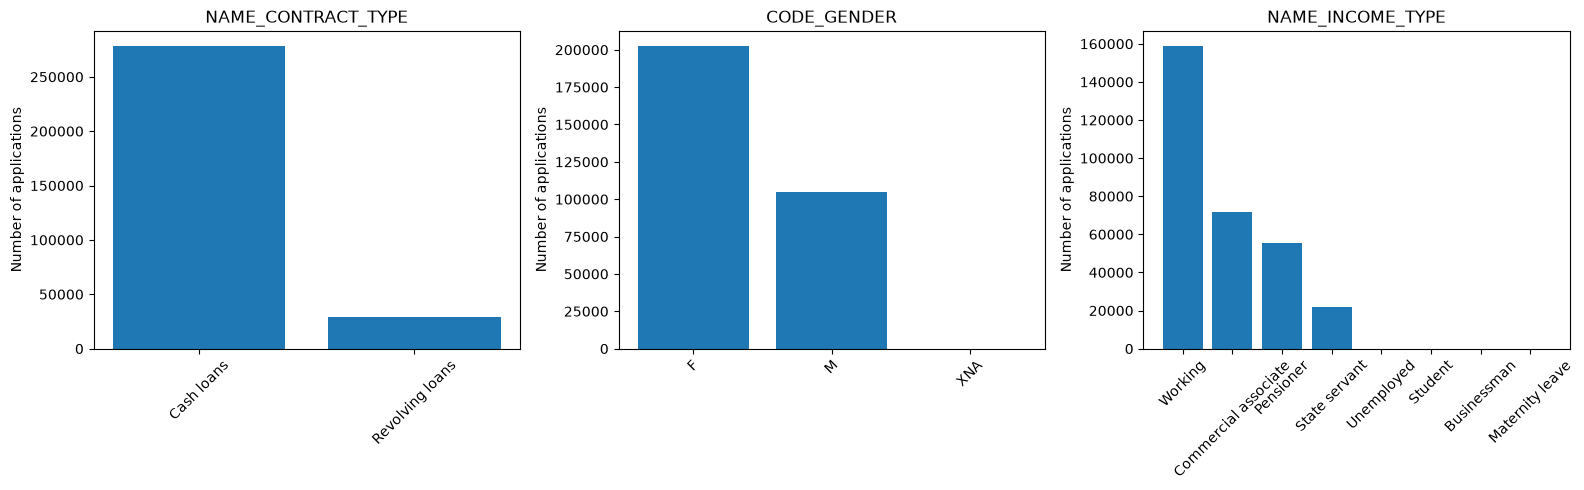

In [17]:
categorical_features_plot = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE"
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, categorical_features_plot):
    counts = df[feature].value_counts().head(10)

    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(feature)
    ax.set_ylabel("Number of applications")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

fig.savefig(
    figures_dir / "eda_categorical_distributions.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

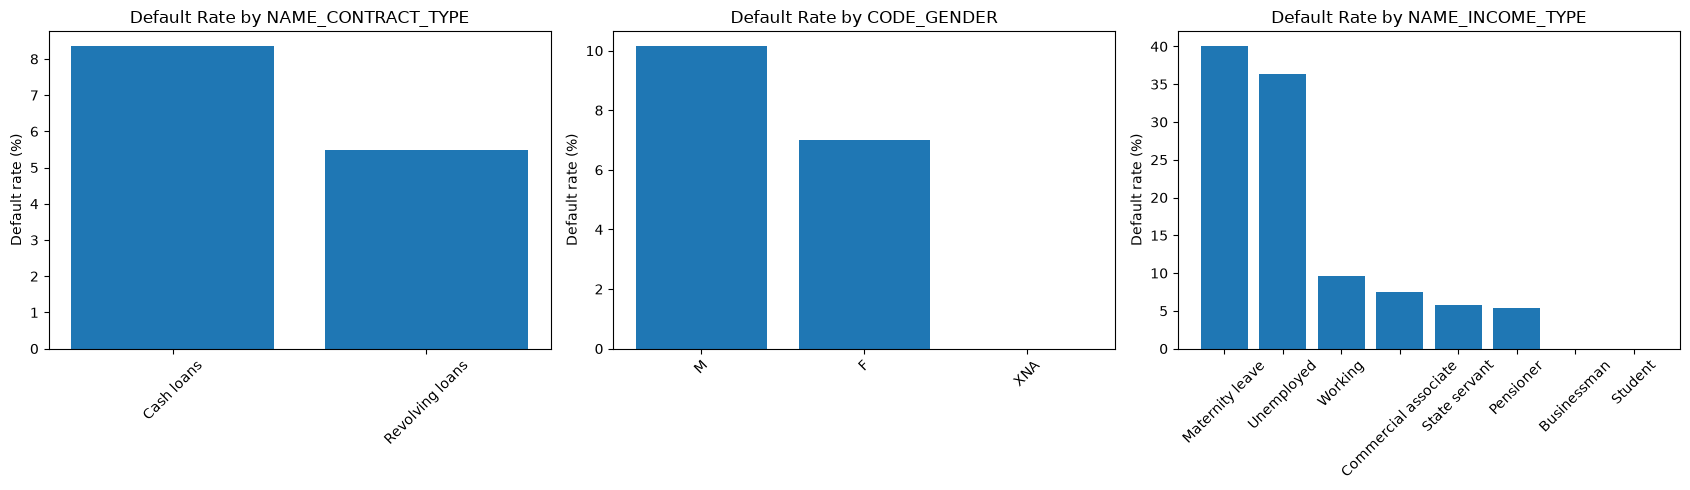

In [18]:
categorical_features_rate = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE"
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feature in zip(axes, categorical_features_rate):

    default_rate = (
        df.groupby(feature)["TARGET"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    ax.bar(
        default_rate.index.astype(str),
        default_rate.values * 100
    )

    ax.set_title(f"Default Rate by {feature}")
    ax.set_ylabel("Default rate (%)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

fig.savefig(
    figures_dir / "eda_categorical_default_rates.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## Key Findings

The exploratory analysis revealed several relevant characteristics of
the Home Credit dataset:

- The dataset contains 307,511 loan applications and 121 explanatory
  variables.
- The target variable is highly imbalanced, with substantially more
  non-default than default observations.
- Several features contain a large proportion of missing values,
  requiring appropriate preprocessing before modeling.
- Financial variables such as `AMT_INCOME_TOTAL`, `AMT_CREDIT`,
  `AMT_ANNUITY`, and `AMT_GOODS_PRICE` show skewed distributions and
  potential extreme values.
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` have the strongest
  negative Pearson correlations with the target among the numerical
  variables.
- Several categorical variables show differences in observed default
  rates across their categories.
- Categories with very few observations should be interpreted with
  caution when comparing default rates.
- The combination of numerical, categorical, and missing data requires
  an appropriate preprocessing strategy before model training.

These findings guide the preprocessing and predictive modeling stages
developed in the following notebooks.

## Conclusions

The exploratory analysis provides an overview of the structure, data
quality, and main patterns present in the Home Credit dataset.

The strong class imbalance makes accuracy unsuitable as the primary
evaluation metric for the classification task. Missing values, skewed
numerical distributions, categorical variables, and potential extreme
values also need to be addressed during preprocessing.

The `EXT_SOURCE` variables stand out because they present the strongest
negative Pearson correlations with the target. However, correlation
measures association and does not imply causality or directly represent
model feature importance.

The observed differences in default rates across categorical variables
also indicate that categorical information may contribute to the
prediction task.

These observations motivate the preprocessing and predictive modeling
strategy developed in `02_Modeling.ipynb`.